In [ ]:
#!pip install -q openpyxl
#!pip install -q matplotlib
!pip install -q statsmodels

In [69]:
import openpyxl
import pandas as pd
import os
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from statsmodels.tsa.arima.model import ARIMA

In [13]:
DATA_PATH = os.getenv("DATA_PATH", "/opt/spark/dados/00_raw/online_retail_II.xlsx")
DATE_COL = "Date"
TARGET_COL = "Sales"

print("DATA_PATH =", DATA_PATH)

DATA_PATH = /opt/spark/dados/00_raw/online_retail_II.xlsx


In [14]:
# 1. Lê o arquivo Excel
df = pd.read_excel(DATA_PATH)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [16]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [17]:
# 2. Converte e salva como CSV
# O parâmetro index=False evita que o Pandas crie uma coluna extra com os índices
df.to_csv("online_retail_II.csv", index=False, encoding='utf-8')

In [18]:
OUT_PATH = "/opt/spark/dados/00_raw/online_retail_II.csv"
df.to_csv(OUT_PATH, index=False, encoding="utf-8")
print("Salvo em:", OUT_PATH)

Salvo em: /opt/spark/dados/00_raw/online_retail_II.csv


In [19]:
print(os.path.exists(OUT_PATH), os.path.getsize(OUT_PATH))

True 46810498


In [22]:
spark = (
    SparkSession.builder
    .appName("Spark_Teste")
    .master("spark://spark-master-rss:7077")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
spark.sparkContext._jsc.sc().setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/02 18:00:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [24]:
PATH = "/opt/spark/dados/00_raw/online_retail_II.csv"

df = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(PATH)
)

df.printSchema()
df.show(10, truncate=False)

root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- Price: double (nullable = true)
 |-- Customer ID: double (nullable = true)
 |-- Country: string (nullable = true)

+-------+---------+-----------------------------------+--------+-------------------+-----+-----------+--------------+
|Invoice|StockCode|Description                        |Quantity|InvoiceDate        |Price|Customer ID|Country       |
+-------+---------+-----------------------------------+--------+-------------------+-----+-----------+--------------+
|489434 |85048    |15CM CHRISTMAS GLASS BALL 20 LIGHTS|12      |2009-12-01 07:45:00|6.95 |13085.0    |United Kingdom|
|489434 |79323P   |PINK CHERRY LIGHTS                 |12      |2009-12-01 07:45:00|6.75 |13085.0    |United Kingdom|
|489434 |79323W   | WHITE CHERRY LIGHTS               |12      |2009-12-01 

In [25]:
# 1) Criar coluna Sales
df1 = df.withColumn("Sales", F.col("Quantity") * F.col("Price"))

# 2) Marcar cancelamentos (Invoices que começam com "C")
df1 = df1.withColumn("is_cancelled", F.col("Invoice").startswith("C"))

df1.select("Invoice","Quantity","Price","Sales","is_cancelled","InvoiceDate").show(10, truncate=False)

+-------+--------+-----+------------------+------------+-------------------+
|Invoice|Quantity|Price|Sales             |is_cancelled|InvoiceDate        |
+-------+--------+-----+------------------+------------+-------------------+
|489434 |12      |6.95 |83.4              |false       |2009-12-01 07:45:00|
|489434 |12      |6.75 |81.0              |false       |2009-12-01 07:45:00|
|489434 |12      |6.75 |81.0              |false       |2009-12-01 07:45:00|
|489434 |48      |2.1  |100.80000000000001|false       |2009-12-01 07:45:00|
|489434 |24      |1.25 |30.0              |false       |2009-12-01 07:45:00|
|489434 |24      |1.65 |39.599999999999994|false       |2009-12-01 07:45:00|
|489434 |24      |1.25 |30.0              |false       |2009-12-01 07:45:00|
|489434 |10      |5.95 |59.5              |false       |2009-12-01 07:45:00|
|489435 |12      |2.55 |30.599999999999998|false       |2009-12-01 07:46:00|
|489435 |12      |3.75 |45.0              |false       |2009-12-01 07:46:00|

In [26]:
df.sample(withReplacement=False, fraction=0.1, seed=42).show(20, truncate=False)

+-------+---------+-----------------------------------+--------+-------------------+-----+-----------+--------------+
|Invoice|StockCode|Description                        |Quantity|InvoiceDate        |Price|Customer ID|Country       |
+-------+---------+-----------------------------------+--------+-------------------+-----+-----------+--------------+
|489434 |21523    |FANCY FONT HOME SWEET HOME DOORMAT |10      |2009-12-01 07:45:00|5.95 |13085.0    |United Kingdom|
|489436 |22119    | PEACE WOODEN BLOCK LETTERS        |3       |2009-12-01 09:06:00|6.95 |13078.0    |United Kingdom|
|489436 |22296    |HEART IVORY TRELLIS LARGE          |12      |2009-12-01 09:06:00|1.65 |13078.0    |United Kingdom|
|489437 |22274    |FELTCRAFT DOLL EMILY               |6       |2009-12-01 09:08:00|2.95 |15362.0    |United Kingdom|
|489438 |20711    |JUMBO BAG TOYS                     |60      |2009-12-01 09:24:00|1.3  |18102.0    |United Kingdom|
|489438 |84032A   |CHARLIE+LOLA PINK HOT WATER BOTTLE |6

In [29]:
df1.sample(withReplacement=False, fraction=0.1, seed=42).show(30, truncate=False)

+-------+---------+-----------------------------------+--------+-------------------+-----+-----------+--------------+-------------------+------------+
|Invoice|StockCode|Description                        |Quantity|InvoiceDate        |Price|Customer ID|Country       |Sales              |is_cancelled|
+-------+---------+-----------------------------------+--------+-------------------+-----+-----------+--------------+-------------------+------------+
|489434 |21523    |FANCY FONT HOME SWEET HOME DOORMAT |10      |2009-12-01 07:45:00|5.95 |13085.0    |United Kingdom|59.5               |false       |
|489436 |22119    | PEACE WOODEN BLOCK LETTERS        |3       |2009-12-01 09:06:00|6.95 |13078.0    |United Kingdom|20.85              |false       |
|489436 |22296    |HEART IVORY TRELLIS LARGE          |12      |2009-12-01 09:06:00|1.65 |13078.0    |United Kingdom|19.799999999999997 |false       |
|489437 |22274    |FELTCRAFT DOLL EMILY               |6       |2009-12-01 09:08:00|2.95 |1536

In [30]:
# Regras de qualidade para "venda válida"
df_clean = (
    df1
    .filter(~F.col("is_cancelled"))      # remove cancelamentos
    .filter(F.col("Quantity") > 0)       # remove devoluções/negativos
    .filter(F.col("Price") > 0)          # remove preços inválidos
    .filter(F.col("InvoiceDate").isNotNull())
)

print("Linhas originais:", df.count())
print("Linhas após limpeza:", df_clean.count())

Linhas originais: 525461


[Stage 14:>                                                         (0 + 4) / 4]

Linhas após limpeza: 511565


In [31]:
# Agregar por dia (padrão forte para forecast)
df_daily = (
    df_clean
    .withColumn("ds", F.to_date("InvoiceDate"))
    .groupBy("ds")
    .agg(F.sum("Sales").alias("y"))
    .orderBy("ds")
)

df_daily.show(10, truncate=False)

+----------+------------------+
|ds        |y                 |
+----------+------------------+
|2009-12-01|54513.500000000255|
|2009-12-02|63352.50999999986 |
|2009-12-03|74037.90999999984 |
|2009-12-04|40732.91999999996 |
|2009-12-05|9803.050000000001 |
|2009-12-06|24613.640000000072|
|2009-12-07|45083.35000000025 |
|2009-12-08|49517.22999999991 |
|2009-12-09|40616.09000000004 |
|2009-12-10|44442.10999999981 |
+----------+------------------+
only showing top 10 rows



In [32]:
# Checagens rápidas
print("Primeira data:", df_daily.agg(F.min("ds")).first()[0])
print("Última data:", df_daily.agg(F.max("ds")).first()[0])
print("N pontos na série:", df_daily.count())

# dias com venda zero (se existirem após agregação)
print("Dias com y <= 0:", df_daily.filter(F.col("y") <= 0).count())

Primeira data: 2009-12-01


Última data: 2010-12-09


N pontos na série: 307


[Stage 38:==============>                                           (1 + 3) / 4]

Dias com y <= 0: 0


In [33]:
# Agregação mensal
df_monthly = (
    df_clean
    .withColumn("ds", F.date_trunc("month", F.col("InvoiceDate")))
    .groupBy("ds")
    .agg(F.sum("Sales").alias("y"))
    .orderBy("ds")
)

df_monthly.show(20, truncate=False)

[Stage 44:==============>                                           (1 + 3) / 4]

+-------------------+------------------+
|ds                 |y                 |
+-------------------+------------------+
|2009-12-01 00:00:00|825685.7600000115 |
|2010-01-01 00:00:00|652708.5019999943 |
|2010-02-01 00:00:00|553339.7360000008 |
|2010-03-01 00:00:00|833570.1309999798 |
|2010-04-01 00:00:00|681528.9919999798 |
|2010-05-01 00:00:00|659858.8599999907 |
|2010-06-01 00:00:00|752270.1399999794 |
|2010-07-01 00:00:00|650712.9399999972 |
|2010-08-01 00:00:00|697274.9099999849 |
|2010-09-01 00:00:00|924333.0109999602 |
|2010-10-01 00:00:00|1165483.9099998919|
|2010-11-01 00:00:00|1470272.4819998266|
|2010-12-01 00:00:00|438852.6500000054 |
+-------------------+------------------+



In [34]:
print("Primeira data:", df_monthly.agg(F.min("ds")).first()[0])
print("Última data:", df_monthly.agg(F.max("ds")).first()[0])
print("N pontos na série:", df_monthly.count())


Primeira data: 2009-12-01 00:00:00


Última data: 2010-12-01 00:00:00


[Stage 59:==============>                                           (1 + 3) / 4]

N pontos na série: 13


In [35]:
OUTPUT_PATH = "/opt/spark/dados/02_silver/online_retail_monthly"
df_monthly.write.mode("overwrite").parquet(OUTPUT_PATH)
print("Salvo em:", OUTPUT_PATH)

Salvo em: /opt/spark/dados/02_silver/online_retail_monthly


In [36]:
from pyspark.sql import functions as F

# Ordenar só para garantir
df_monthly = df_monthly.orderBy("ds")

# Definir corte: últimos 3 meses para teste
cutoff_date = df_monthly.orderBy("ds").collect()[-4]["ds"]

train = df_monthly.filter(F.col("ds") <= cutoff_date)
test  = df_monthly.filter(F.col("ds") > cutoff_date)

print("Treino:", train.count())
print("Teste:", test.count())

train.show()
test.show()

Treino: 10


[Stage 87:==============>                                           (1 + 3) / 4]

Teste: 3


+-------------------+-----------------+
|                 ds|                y|
+-------------------+-----------------+
|2009-12-01 00:00:00|825685.7600000115|
|2010-01-01 00:00:00|652708.5019999943|
|2010-02-01 00:00:00|553339.7360000008|
|2010-03-01 00:00:00|833570.1309999798|
|2010-04-01 00:00:00|681528.9919999798|
|2010-05-01 00:00:00|659858.8599999907|
|2010-06-01 00:00:00|752270.1399999794|
|2010-07-01 00:00:00|650712.9399999972|
|2010-08-01 00:00:00|697274.9099999849|
|2010-09-01 00:00:00|924333.0109999602|
+-------------------+-----------------+

+-------------------+------------------+
|                 ds|                 y|
+-------------------+------------------+
|2010-10-01 00:00:00|1165483.9099998919|
|2010-11-01 00:00:00|1470272.4819998266|
|2010-12-01 00:00:00| 438852.6500000054|
+-------------------+------------------+



In [37]:
last_value = train.orderBy("ds", ascending=False).first()["y"]

print("Último valor treino:", last_value)

# Criar previsão constante para os meses de teste
forecast_naive = (
    test
    .withColumn("y_hat", F.lit(last_value))
)

forecast_naive.show()

Último valor treino: 924333.0109999602


[Stage 102:==============>                                          (1 + 3) / 4]

+-------------------+------------------+-----------------+
|                 ds|                 y|            y_hat|
+-------------------+------------------+-----------------+
|2010-10-01 00:00:00|1165483.9099998919|924333.0109999602|
|2010-11-01 00:00:00|1470272.4819998266|924333.0109999602|
|2010-12-01 00:00:00| 438852.6500000054|924333.0109999602|
+-------------------+------------------+-----------------+



In [38]:
from pyspark.sql.functions import abs as F_abs

mae = (
    forecast_naive
    .withColumn("abs_error", F_abs(F.col("y") - F.col("y_hat")))
    .agg(F.avg("abs_error"))
    .first()[0]
)

print("MAE Baseline:", mae)

MAE Baseline: 424190.2436665843


In [48]:
df_plot = (
    train
    .withColumn("type", F.lit("train"))
    .unionByName(
        forecast_naive.select(["y", "ds", "y_hat"])
    )
)

df_plot.show()

AnalysisException: Cannot resolve column name "type" among (y, ds, y_hat).

In [41]:
from pyspark.sql import functions as F

# --- Parte 1: Série real (treino + teste) ---
actual_train = (
    train
    .select("ds", "y")
    .withColumn("y_hat", F.lit(None).cast("double"))
    .withColumn("split", F.lit("train"))
    .withColumn("series", F.lit("actual"))
)

actual_test = (
    test
    .select("ds", "y")
    .withColumn("y_hat", F.lit(None).cast("double"))
    .withColumn("split", F.lit("test"))
    .withColumn("series", F.lit("actual"))
)

# --- Parte 2: Previsão (naive) para o período de teste ---
pred_test = (
    forecast_naive
    .select("ds", "y", "y_hat")
    .withColumn("split", F.lit("test"))
    .withColumn("series", F.lit("forecast"))
)

# --- União final (schema idêntico) ---
df_plot = (
    actual_train
    .unionByName(actual_test)
    .unionByName(pred_test)
    .orderBy("ds", "series")  # "actual" e "forecast" aparecem juntos
)

df_plot.show(50, truncate=False)
df_plot.printSchema()

+-------------------+------------------+-----------------+-----+--------+
|ds                 |y                 |y_hat            |split|series  |
+-------------------+------------------+-----------------+-----+--------+
|2009-12-01 00:00:00|825685.7600000115 |NULL             |train|actual  |
|2010-01-01 00:00:00|652708.5019999943 |NULL             |train|actual  |
|2010-02-01 00:00:00|553339.7360000008 |NULL             |train|actual  |
|2010-03-01 00:00:00|833570.1309999798 |NULL             |train|actual  |
|2010-04-01 00:00:00|681528.9919999798 |NULL             |train|actual  |
|2010-05-01 00:00:00|659858.8599999907 |NULL             |train|actual  |
|2010-06-01 00:00:00|752270.1399999794 |NULL             |train|actual  |
|2010-07-01 00:00:00|650712.9399999972 |NULL             |train|actual  |
|2010-08-01 00:00:00|697274.9099999849 |NULL             |train|actual  |
|2010-09-01 00:00:00|924333.0109999602 |NULL             |train|actual  |
|2010-10-01 00:00:00|1165483.909999891

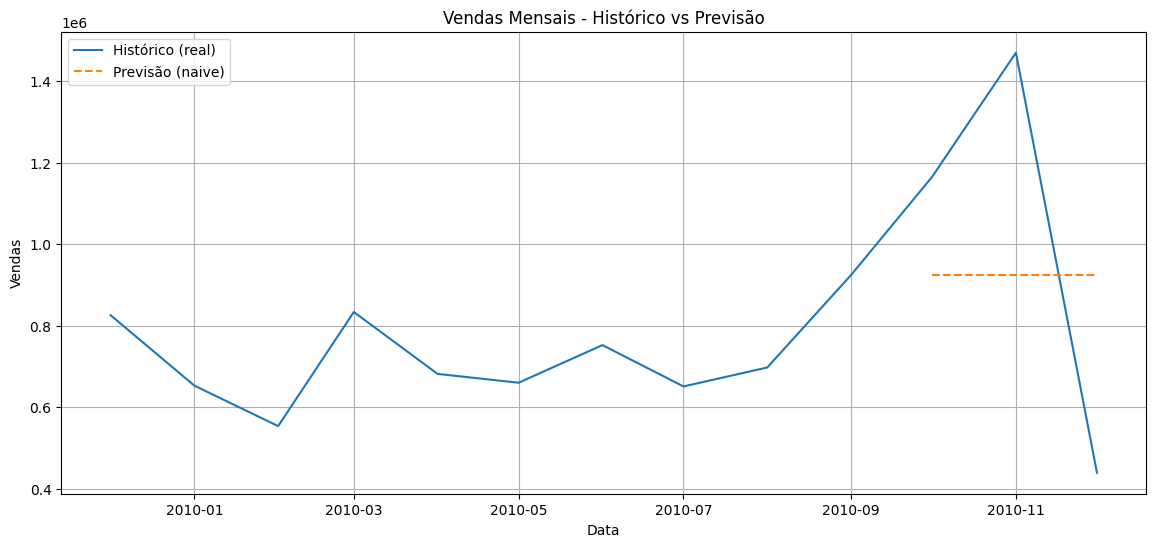

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

pdf = df_plot.toPandas()
pdf["ds"] = pd.to_datetime(pdf["ds"])

# separar
pdf_actual = pdf[pdf["series"] == "actual"].sort_values("ds")
pdf_fore  = pdf[pdf["series"] == "forecast"].sort_values("ds")

plt.figure(figsize=(14,6))
plt.plot(pdf_actual["ds"], pdf_actual["y"], label="Histórico (real)")
plt.plot(pdf_fore["ds"], pdf_fore["y_hat"], linestyle="--", label="Previsão (naive)")
plt.title("Vendas Mensais - Histórico vs Previsão")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.legend()
plt.grid(True)
plt.show()

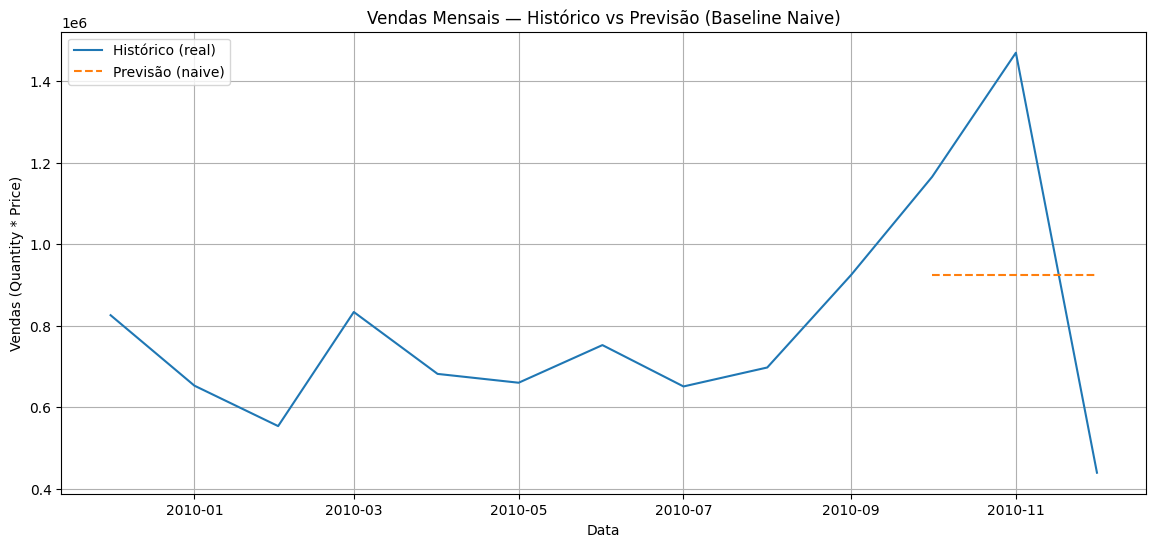

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

pdf = df_plot.toPandas()
pdf["ds"] = pd.to_datetime(pdf["ds"])

# separa real vs previsão
pdf_actual = pdf[pdf["series"] == "actual"].sort_values("ds")
pdf_fore   = pdf[pdf["series"] == "forecast"].sort_values("ds")

plt.figure(figsize=(14,6))
plt.plot(pdf_actual["ds"], pdf_actual["y"], label="Histórico (real)")
plt.plot(pdf_fore["ds"], pdf_fore["y_hat"], linestyle="--", label="Previsão (naive)")

plt.title("Vendas Mensais — Histórico vs Previsão (Baseline Naive)")
plt.xlabel("Data")
plt.ylabel("Vendas (Quantity * Price)")
plt.legend()
plt.grid(True)
plt.show()

In [51]:
from pyspark.sql import functions as F

# Descobrir última data original do dataset limpo
max_date = df_clean.agg(F.max("InvoiceDate")).first()[0]
print("Última data real:", max_date)

# Criar coluna mês final
last_month = max_date.strftime("%Y-%m")
print("Último mês parcial:", last_month)

Última data real: 2010-12-09 20:01:00
Último mês parcial: 2010-12


In [52]:
df_monthly_clean = (
    df_monthly
    .filter(F.date_format("ds", "yyyy-MM") != last_month)
    .orderBy("ds")
)

df_monthly_clean.show()
print("Novo total de meses:", df_monthly_clean.count())

+-------------------+------------------+
|                 ds|                 y|
+-------------------+------------------+
|2009-12-01 00:00:00| 825685.7600000115|
|2010-01-01 00:00:00| 652708.5019999943|
|2010-02-01 00:00:00| 553339.7360000008|
|2010-03-01 00:00:00| 833570.1309999798|
|2010-04-01 00:00:00| 681528.9919999798|
|2010-05-01 00:00:00| 659858.8599999907|
|2010-06-01 00:00:00| 752270.1399999794|
|2010-07-01 00:00:00| 650712.9399999972|
|2010-08-01 00:00:00| 697274.9099999849|
|2010-09-01 00:00:00| 924333.0109999602|
|2010-10-01 00:00:00|1165483.9099998919|
|2010-11-01 00:00:00|1470272.4819998266|
+-------------------+------------------+



[Stage 170:>                                                        (0 + 4) / 4]

Novo total de meses: 12


In [53]:
df_monthly_clean = df_monthly_clean.orderBy("ds")

cutoff_date = df_monthly_clean.orderBy("ds").collect()[-4]["ds"]

train = df_monthly_clean.filter(F.col("ds") <= cutoff_date)
test  = df_monthly_clean.filter(F.col("ds") > cutoff_date)

print("Treino:", train.count())
print("Teste:", test.count())

Treino: 9


[Stage 190:==============>                                          (1 + 3) / 4]

Teste: 3


In [54]:
last_value = train.orderBy("ds", ascending=False).first()["y"]
print("Último valor do treino:", last_value)

[Stage 196:>                                                        (0 + 4) / 4]

Último valor do treino: 697274.9099999849


In [55]:
from pyspark.sql import functions as F

forecast_naive = (
    test
    .withColumn("y_hat", F.lit(last_value))
)

forecast_naive.show()

[Stage 199:>                                                        (0 + 4) / 4]

+-------------------+------------------+-----------------+
|                 ds|                 y|            y_hat|
+-------------------+------------------+-----------------+
|2010-09-01 00:00:00| 924333.0109999602|697274.9099999849|
|2010-10-01 00:00:00|1165483.9099998919|697274.9099999849|
|2010-11-01 00:00:00|1470272.4819998266|697274.9099999849|
+-------------------+------------------+-----------------+



In [56]:
from pyspark.sql.functions import abs as F_abs

mae = (
    forecast_naive
    .withColumn("abs_error", F_abs(F.col("y") - F.col("y_hat")))
    .agg(F.avg("abs_error"))
    .first()[0]
)

print("MAE Baseline (corrigido):", mae)

MAE Baseline (corrigido): 489421.55766657466


In [57]:
# Série real
actual_train = (
    train
    .select("ds", "y")
    .withColumn("y_hat", F.lit(None).cast("double"))
    .withColumn("series", F.lit("actual"))
)

actual_test = (
    test
    .select("ds", "y")
    .withColumn("y_hat", F.lit(None).cast("double"))
    .withColumn("series", F.lit("actual"))
)

# Forecast
pred_test = (
    forecast_naive
    .select("ds", "y", "y_hat")
    .withColumn("series", F.lit("forecast"))
)

df_plot = (
    actual_train
    .unionByName(actual_test)
    .unionByName(pred_test)
    .orderBy("ds", "series")
)

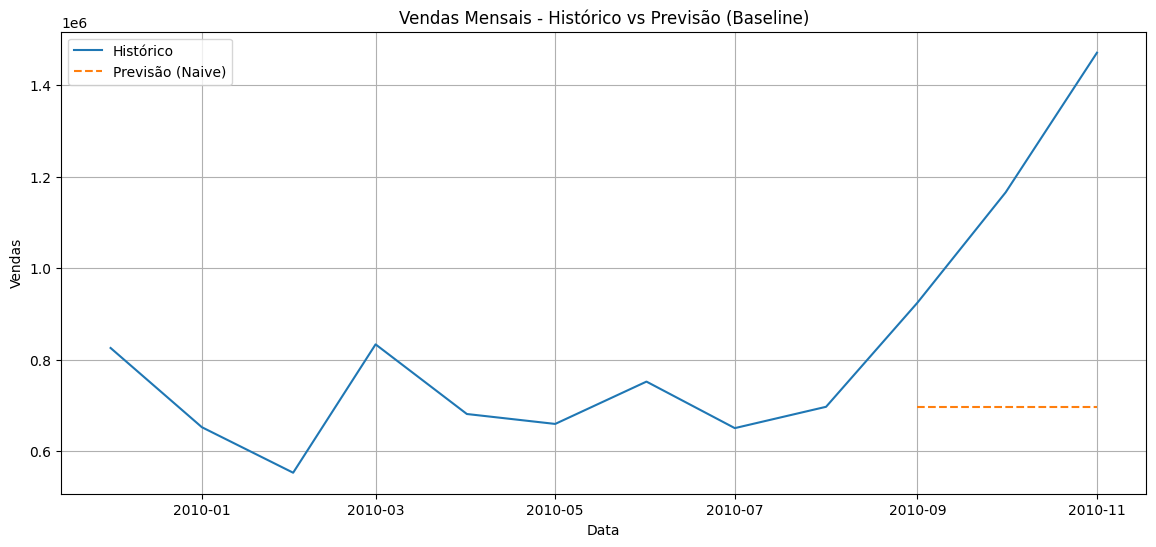

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

pdf = df_plot.toPandas()
pdf["ds"] = pd.to_datetime(pdf["ds"])

pdf_actual = pdf[pdf["series"] == "actual"].sort_values("ds")
pdf_fore  = pdf[pdf["series"] == "forecast"].sort_values("ds")

plt.figure(figsize=(14,6))
plt.plot(pdf_actual["ds"], pdf_actual["y"], label="Histórico")
plt.plot(pdf_fore["ds"], pdf_fore["y_hat"], linestyle="--", label="Previsão (Naive)")
plt.title("Vendas Mensais - Histórico vs Previsão (Baseline)")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.legend()
plt.grid(True)
plt.show()

In [59]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Criar índice temporal
w = Window.orderBy("ds")

df_reg = (
    df_monthly_clean
    .withColumn("t", F.row_number().over(w) - 1)
)

df_reg.show()

[Stage 240:==============>                                          (1 + 3) / 4]

+-------------------+------------------+---+
|                 ds|                 y|  t|
+-------------------+------------------+---+
|2009-12-01 00:00:00| 825685.7600000115|  0|
|2010-01-01 00:00:00| 652708.5019999943|  1|
|2010-02-01 00:00:00| 553339.7360000008|  2|
|2010-03-01 00:00:00| 833570.1309999798|  3|
|2010-04-01 00:00:00| 681528.9919999798|  4|
|2010-05-01 00:00:00| 659858.8599999907|  5|
|2010-06-01 00:00:00| 752270.1399999794|  6|
|2010-07-01 00:00:00| 650712.9399999972|  7|
|2010-08-01 00:00:00| 697274.9099999849|  8|
|2010-09-01 00:00:00| 924333.0109999602|  9|
|2010-10-01 00:00:00|1165483.9099998919| 10|
|2010-11-01 00:00:00|1470272.4819998266| 11|
+-------------------+------------------+---+



In [60]:
cutoff = df_reg.orderBy("ds").collect()[-4]["ds"]

train_reg = df_reg.filter(F.col("ds") <= cutoff)
test_reg  = df_reg.filter(F.col("ds") > cutoff)

print("Treino:", train_reg.count())
print("Teste:", test_reg.count())

Treino: 9
Teste: 3


In [61]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression

assembler = VectorAssembler(
    inputCols=["t"],
    outputCol="features"
)

train_vec = assembler.transform(train_reg)

lr = LinearRegression(featuresCol="features", labelCol="y")
model_lr = lr.fit(train_vec)

print("Intercept:", model_lr.intercept)
print("Coeficiente:", model_lr.coefficients)

Intercept: 720470.9222666668
Coeficiente: [-4924.675816668967]


In [62]:
test_vec = assembler.transform(test_reg)

pred_lr = model_lr.transform(test_vec)

pred_lr.select("ds","y","prediction").show()

+-------------------+------------------+-----------------+
|                 ds|                 y|       prediction|
+-------------------+------------------+-----------------+
|2010-09-01 00:00:00| 924333.0109999602| 676148.839916646|
|2010-10-01 00:00:00|1165483.9099998919|671224.1640999771|
|2010-11-01 00:00:00|1470272.4819998266|666299.4882833081|
+-------------------+------------------+-----------------+



In [63]:
from pyspark.sql.functions import abs as F_abs

mae_lr = (
    pred_lr
    .withColumn("abs_error", F_abs(F.col("y") - F.col("prediction")))
    .agg(F.avg("abs_error"))
    .first()[0]
)

print("MAE Regressão:", mae_lr)

MAE Regressão: 515472.3035665825


In [64]:
import pandas as pd

pdf_series = df_monthly_clean.orderBy("ds").toPandas()
pdf_series["ds"] = pd.to_datetime(pdf_series["ds"])
pdf_series = pdf_series.set_index("ds")

pdf_series

,y
ds,
2009-12-01,825685.760
2010-01-01,652708.502
2010-02-01,553339.736
2010-03-01,833570.131
2010-04-01,681528.992
2010-05-01,659858.860
2010-06-01,752270.140
2010-07-01,650712.940
2010-08-01,697274.910


In [70]:
from statsmodels.tsa.arima.model import ARIMA

# split pandas
train_pd = pdf_series.iloc[:-3]
test_pd  = pdf_series.iloc[-3:]

model_arima = ARIMA(train_pd["y"], order=(1,1,1))
model_arima_fit = model_arima.fit()

forecast_arima = model_arima_fit.forecast(steps=3)

forecast_arima

/usr/local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


2010-09-01    690162.501989
2010-10-01    690161.851258
2010-11-01    690161.851198
Freq: MS, Name: predicted_mean, dtype: float64

In [71]:
import numpy as np

mae_arima = np.mean(np.abs(test_pd["y"].values - forecast_arima.values))
print("MAE ARIMA:", mae_arima)

MAE ARIMA: 496534.39951824275


In [72]:
from pyspark.sql import functions as F

df_weekly = (
    df_clean
    .withColumn("week_start", F.date_trunc("week", F.col("InvoiceDate")))
    .groupBy("week_start")
    .agg(F.sum(F.col("Quantity") * F.col("Price")).alias("y"))
    .orderBy("week_start")
    .withColumnRenamed("week_start", "ds")
)

print("N pontos semanais:", df_weekly.count())
df_weekly.show(10, truncate=False)

N pontos semanais: 53
+-------------------+------------------+
|ds                 |y                 |
+-------------------+------------------+
|2009-11-30 00:00:00|267053.53000000573|
|2009-12-07 00:00:00|241631.4700000038 |
|2009-12-14 00:00:00|261738.39000000438|
|2009-12-21 00:00:00|55262.37000000024 |
|2010-01-04 00:00:00|168520.110000001  |
|2010-01-11 00:00:00|163999.72000000294|
|2010-01-18 00:00:00|154221.30100000117|
|2010-01-25 00:00:00|165967.3710000018 |
|2010-02-01 00:00:00|124664.071999999  |
|2010-02-08 00:00:00|91110.60999999986 |
+-------------------+------------------+
only showing top 10 rows



In [73]:
from pyspark.sql.window import Window

w = Window.orderBy("ds")

df_feat = (
    df_weekly
    .withColumn("lag_1", F.lag("y", 1).over(w))
    .withColumn("lag_2", F.lag("y", 2).over(w))
    .withColumn("lag_3", F.lag("y", 3).over(w))
    .withColumn("ma_3", (F.col("lag_1") + F.col("lag_2") + F.col("lag_3")) / 3)
    .withColumn("y_next", F.lead("y", 1).over(w))   # target = próxima semana
    .filter(F.col("lag_3").isNotNull())
    .filter(F.col("y_next").isNotNull())
)

df_feat.select("ds","y","lag_1","lag_2","lag_3","ma_3","y_next").show(10, truncate=False)
print("Linhas para treino:", df_feat.count())

+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|ds                 |y                 |lag_1             |lag_2             |lag_3             |ma_3              |y_next            |
+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|2009-12-21 00:00:00|55262.37000000024 |261738.39000000438|241631.4700000038 |267053.53000000573|256807.7966666713 |168520.110000001  |
|2010-01-04 00:00:00|168520.110000001  |55262.37000000024 |261738.39000000438|241631.4700000038 |186210.7433333361 |163999.72000000294|
|2010-01-11 00:00:00|163999.72000000294|168520.110000001  |55262.37000000024 |261738.39000000438|161840.29000000187|154221.30100000117|
|2010-01-18 00:00:00|154221.30100000117|163999.72000000294|168520.110000001  |55262.37000000024 |129260.73333333472|165967.3710000018 |
|2010-01-25 00:00:00|165967.3710000018 |154221.3

In [74]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.sql.functions import abs as F_abs

# Split temporal: últimas 8 semanas como teste (ajuste se quiser)
cutoff = df_feat.orderBy("ds").collect()[-9]["ds"]
train = df_feat.filter(F.col("ds") <= cutoff)
test  = df_feat.filter(F.col("ds") > cutoff)

assembler = VectorAssembler(inputCols=["lag_1","lag_2","lag_3","ma_3"], outputCol="features")
train_v = assembler.transform(train)
test_v  = assembler.transform(test)

lr = LinearRegression(featuresCol="features", labelCol="y_next")
m = lr.fit(train_v)

pred = m.transform(test_v).select("ds","y_next","prediction")

mae = (
    pred.withColumn("abs_error", F_abs(F.col("y_next") - F.col("prediction")))
        .agg(F.avg("abs_error")).first()[0]
)

print("MAE (supervisionado - LR):", mae)
pred.show(20, truncate=False)

MAE (supervisionado - LR): 67645.18230510654
+-------------------+------------------+------------------+
|ds                 |y_next            |prediction        |
+-------------------+------------------+------------------+
|2010-10-11 00:00:00|246809.32000000606|236837.3740746632 |
|2010-10-18 00:00:00|220689.65000000445|240067.59647517337|
|2010-10-25 00:00:00|288871.07000000455|213596.10589634546|
|2010-11-01 00:00:00|382123.5810000131 |191979.2919648901 |
|2010-11-08 00:00:00|355559.84100001067|223384.1940918173 |
|2010-11-15 00:00:00|304424.85000001243|270692.605062787  |
|2010-11-22 00:00:00|324720.9700000097 |264237.41622663476|
|2010-11-29 00:00:00|253424.82000000437|233423.95271723968|
+-------------------+------------------+------------------+



In [75]:
print("Total de linhas supervisionadas:", df_feat.count())
df_feat.orderBy("ds").show(10, truncate=False)

Total de linhas supervisionadas: 49
+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|ds                 |y                 |lag_1             |lag_2             |lag_3             |ma_3              |y_next            |
+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|2009-12-21 00:00:00|55262.37000000024 |261738.39000000438|241631.4700000038 |267053.53000000573|256807.7966666713 |168520.110000001  |
|2010-01-04 00:00:00|168520.110000001  |55262.37000000024 |261738.39000000438|241631.4700000038 |186210.7433333361 |163999.72000000294|
|2010-01-11 00:00:00|163999.72000000294|168520.110000001  |55262.37000000024 |261738.39000000438|161840.29000000187|154221.30100000117|
|2010-01-18 00:00:00|154221.30100000117|163999.72000000294|168520.110000001  |55262.37000000024 |129260.73333333472|165967.3710000018 |
|2010-01-25 

In [76]:
total_rows = df_feat.count()
split_index = int(total_rows * 0.8)

cutoff = (
    df_feat
    .orderBy("ds")
    .collect()[split_index]["ds"]
)

train = df_feat.filter(F.col("ds") <= cutoff)
test  = df_feat.filter(F.col("ds") > cutoff)

print("Treino:", train.count())
print("Teste:", test.count())

Treino: 40


Teste: 9


In [77]:
pred_lr = m.transform(test_v).select("ds","y_next","prediction")

pred_lr.show()

+-------------------+------------------+------------------+
|                 ds|            y_next|        prediction|
+-------------------+------------------+------------------+
|2010-10-11 00:00:00|246809.32000000606| 236837.3740746632|
|2010-10-18 00:00:00|220689.65000000445|240067.59647517337|
|2010-10-25 00:00:00|288871.07000000455|213596.10589634546|
|2010-11-01 00:00:00| 382123.5810000131| 191979.2919648901|
|2010-11-08 00:00:00|355559.84100001067| 223384.1940918173|
|2010-11-15 00:00:00|304424.85000001243|  270692.605062787|
|2010-11-22 00:00:00| 324720.9700000097|264237.41622663476|
|2010-11-29 00:00:00|253424.82000000437|233423.95271723968|
+-------------------+------------------+------------------+



In [78]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="y_next",
    numTrees=100,
    maxDepth=5
)

model_rf = rf.fit(train_v)
pred_rf = model_rf.transform(test_v).select("ds","y_next","prediction")

mae_rf = (
    pred_rf
    .withColumn("abs_error", F_abs(F.col("y_next") - F.col("prediction")))
    .agg(F.avg("abs_error"))
    .first()[0]
)

print("MAE Random Forest:", mae_rf)

MAE Random Forest: 84224.69357627493


In [79]:
print("Coeficientes:")
for name, coef in zip(["lag_1","lag_2","lag_3","ma_3"], m.coefficients):
    print(f"{name}: {coef}")

Coeficientes:
lag_1: 0.3305395896956058
lag_2: 0.023161879358216664
lag_3: -0.15593381604391662
ma_3: 0.24016569706990684


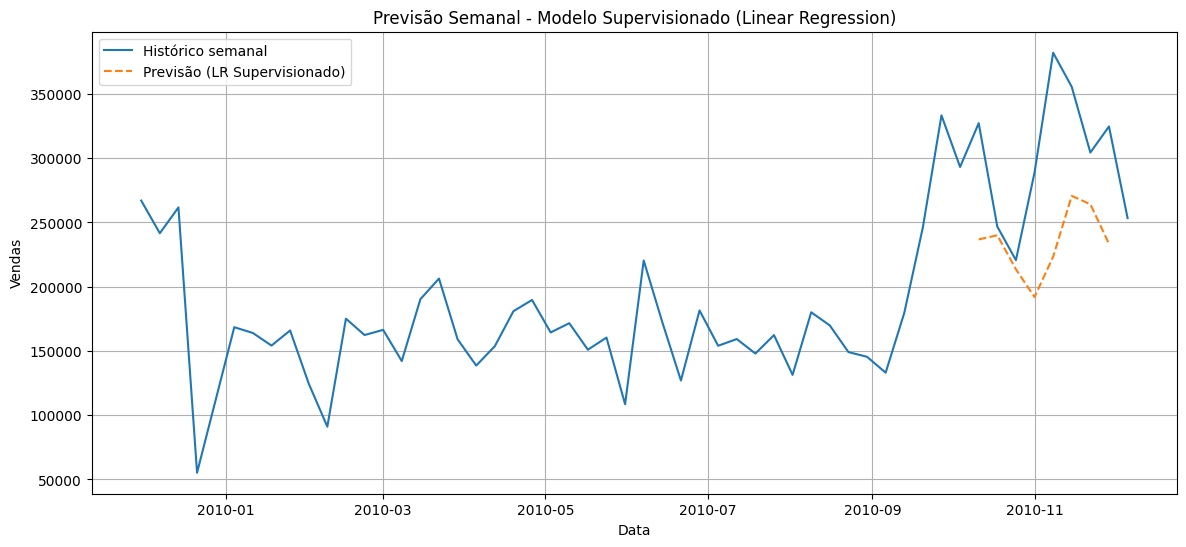

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

# Converter para pandas
pred_pd = pred_lr.toPandas()
pred_pd["ds"] = pd.to_datetime(pred_pd["ds"])

# Histórico real semanal
real_pd = df_weekly.toPandas()
real_pd["ds"] = pd.to_datetime(real_pd["ds"])

plt.figure(figsize=(14,6))
plt.plot(real_pd["ds"], real_pd["y"], label="Histórico semanal")
plt.plot(pred_pd["ds"], pred_pd["prediction"], linestyle="--", label="Previsão (LR Supervisionado)")
plt.title("Previsão Semanal - Modelo Supervisionado (Linear Regression)")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.legend()
plt.grid(True)
plt.show()

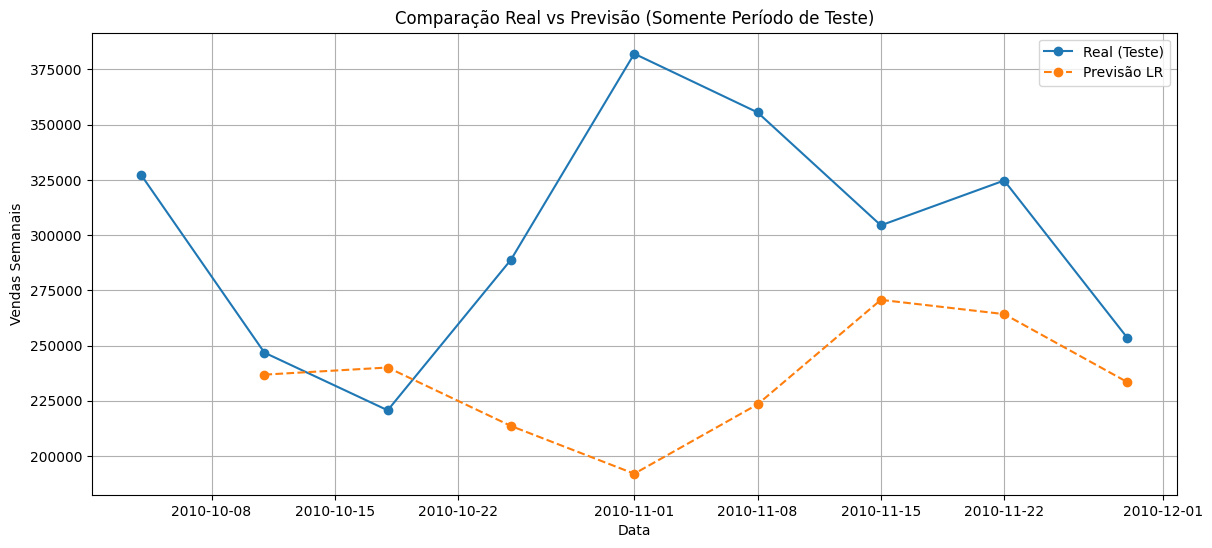

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

pred_pd = pred_lr.toPandas()
pred_pd["ds"] = pd.to_datetime(pred_pd["ds"])

test_pd = test.toPandas()
test_pd["ds"] = pd.to_datetime(test_pd["ds"])

plt.figure(figsize=(14,6))
plt.plot(test_pd["ds"], test_pd["y_next"], marker="o", label="Real (Teste)")
plt.plot(pred_pd["ds"], pred_pd["prediction"], marker="o", linestyle="--", label="Previsão LR")

plt.title("Comparação Real vs Previsão (Somente Período de Teste)")
plt.xlabel("Data")
plt.ylabel("Vendas Semanais")
plt.legend()
plt.grid(True)
plt.show()

In [82]:
import numpy as np

mape = np.mean(np.abs((test_pd["y_next"].values - pred_pd["prediction"].values) / test_pd["y_next"].values)) * 100

print("MAPE (%):", mape)

ValueError: operands could not be broadcast together with shapes (9,) (8,) 

In [84]:
from pyspark.sql.functions import abs as F_abs

mape_spark = (
    pred_lr
    .withColumn("pct_error", F_abs((F.col("y_next") - F.col("prediction")) / F.col("y_next")))
    .agg(F.avg("pct_error"))
    .first()[0] * 100
)

print("MAPE (%):", mape_spark)

MAPE (%): 20.426542663533876


In [85]:
pred_pd["real"] = test_pd["y_next"].values
pred_pd["residual"] = pred_pd["real"] - pred_pd["prediction"]

pred_pd[["ds","real","prediction","residual"]]

ValueError: Length of values (9) does not match length of index (8)

In [86]:
from pyspark.sql import functions as F

eval_df = (
    pred_lr
    .select("ds", "y_next", "prediction")
    .withColumn("residual", F.col("y_next") - F.col("prediction"))
    .withColumn("abs_error", F.abs(F.col("residual")))
    .withColumn("pct_error", F.abs(F.col("residual") / F.col("y_next")))
    .orderBy("ds")
)

eval_df.show(50, truncate=False)

+-------------------+------------------+------------------+-------------------+------------------+--------------------+
|ds                 |y_next            |prediction        |residual           |abs_error         |pct_error           |
+-------------------+------------------+------------------+-------------------+------------------+--------------------+
|2010-10-11 00:00:00|246809.32000000606|236837.3740746632 |9971.94592534285   |9971.94592534285  |0.040403441512429944|
|2010-10-18 00:00:00|220689.65000000445|240067.59647517337|-19377.946475168923|19377.946475168923|0.08780632202356808 |
|2010-10-25 00:00:00|288871.07000000455|213596.10589634546|75274.96410365909  |75274.96410365909 |0.26058325641144303 |
|2010-11-01 00:00:00|382123.5810000131 |191979.2919648901 |190144.28903512302 |190144.28903512302|0.4975989404723926  |
|2010-11-08 00:00:00|355559.84100001067|223384.1940918173 |132175.64690819336 |132175.64690819336|0.3717395264224719  |
|2010-11-15 00:00:00|304424.85000001243|

In [87]:
metrics = (
    eval_df
    .agg(
        F.avg("abs_error").alias("MAE"),
        (F.avg("pct_error") * 100).alias("MAPE_pct")
    )
    .first()
)

print("MAE:", metrics["MAE"])
print("MAPE (%):", metrics["MAPE_pct"])

MAE: 67645.18230510654
MAPE (%): 20.426542663533876


In [88]:
pred_pd = pred_lr.select("ds","y_next","prediction").toPandas()
pred_pd["ds"] = pd.to_datetime(pred_pd["ds"])

test_pd = test.select("ds","y_next").toPandas()
test_pd["ds"] = pd.to_datetime(test_pd["ds"])

merged = test_pd.merge(pred_pd, on="ds", how="inner")  # inner alinha somente datas em comum
merged["residual"] = merged["y_next"] - merged["prediction"]
merged["pct_error"] = (merged["residual"].abs() / merged["y_next"]) * 100

display(merged)
print("MAPE (%):", merged["pct_error"].mean())

KeyError: 'y_next'

In [89]:
from pyspark.sql import functions as F

eval_df = (
    pred_lr
    .select("ds", "y_next", "prediction")
    .withColumn("residual", F.col("y_next") - F.col("prediction"))
    .withColumn("abs_error", F.abs(F.col("residual")))
    .withColumn("pct_error", F.abs(F.col("residual") / F.col("y_next")))
    .orderBy("ds")
)

eval_df.show(50, truncate=False)

metrics = (
    eval_df
    .agg(
        F.avg("abs_error").alias("MAE"),
        (F.avg("pct_error") * 100).alias("MAPE_pct")
    )
    .first()
)

print("MAE:", metrics["MAE"])
print("MAPE (%):", metrics["MAPE_pct"])

+-------------------+------------------+------------------+-------------------+------------------+--------------------+
|ds                 |y_next            |prediction        |residual           |abs_error         |pct_error           |
+-------------------+------------------+------------------+-------------------+------------------+--------------------+
|2010-10-11 00:00:00|246809.32000000606|236837.3740746632 |9971.94592534285   |9971.94592534285  |0.040403441512429944|
|2010-10-18 00:00:00|220689.65000000445|240067.59647517337|-19377.946475168923|19377.946475168923|0.08780632202356808 |
|2010-10-25 00:00:00|288871.07000000455|213596.10589634546|75274.96410365909  |75274.96410365909 |0.26058325641144303 |
|2010-11-01 00:00:00|382123.5810000131 |191979.2919648901 |190144.28903512302 |190144.28903512302|0.4975989404723926  |
|2010-11-08 00:00:00|355559.84100001067|223384.1940918173 |132175.64690819336 |132175.64690819336|0.3717395264224719  |
|2010-11-15 00:00:00|304424.85000001243|

In [90]:
print("COLUNAS merged:", list(merged.columns))
merged.head()

COLUNAS merged: ['ds', 'y_next_x', 'y_next_y', 'prediction']


,ds,y_next_x,y_next_y,prediction
0,2010-10-11,246809.320,246809.320,236837.374075
1,2010-10-18,220689.650,220689.650,240067.596475
2,2010-10-25,288871.070,288871.070,213596.105896
3,2010-11-01,382123.581,382123.581,191979.291965
4,2010-11-08,355559.841,355559.841,223384.194092


In [91]:
# tenta achar a coluna real automaticamente
target_col = "y_next" if "y_next" in merged.columns else ("y" if "y" in merged.columns else None)
if target_col is None:
    raise ValueError(f"Não achei target (y_next ou y). Colunas: {list(merged.columns)}")

merged["residual"] = merged[target_col] - merged["prediction"]
merged["pct_error"] = (merged["residual"].abs() / merged[target_col]) * 100

display(merged)
print("MAPE (%):", merged["pct_error"].mean())

ValueError: Não achei target (y_next ou y). Colunas: ['ds', 'y_next_x', 'y_next_y', 'prediction']

In [92]:
pred_pd = pred_lr.select("ds","prediction").toPandas()
pred_pd["ds"] = pd.to_datetime(pred_pd["ds"])

test_pd = test.select("ds","y_next").toPandas()
test_pd["ds"] = pd.to_datetime(test_pd["ds"])

merged = test_pd.merge(pred_pd, on="ds", how="inner")

merged["residual"] = merged["y_next"] - merged["prediction"]
merged["pct_error"] = (merged["residual"].abs() / merged["y_next"]) * 100

display(merged)
print("MAPE (%):", merged["pct_error"].mean())
print("MAE:", merged["residual"].abs().mean())

,ds,y_next,prediction,residual,pct_error
0,2010-10-11,246809.320,236837.374075,9971.945925,4.040344
1,2010-10-18,220689.650,240067.596475,-19377.946475,8.780632
2,2010-10-25,288871.070,213596.105896,75274.964104,26.058326
3,2010-11-01,382123.581,191979.291965,190144.289035,49.759894
4,2010-11-08,355559.841,223384.194092,132175.646908,37.173953
5,2010-11-15,304424.850,270692.605063,33732.244937,11.080648
6,2010-11-22,324720.970,264237.416227,60483.553773,18.626316
7,2010-11-29,253424.820,233423.952717,20000.867283,7.892229


MAPE (%): 20.426542663533876
MAE: 67645.18230510654
